# Resource Perspective — Drift Exploration

Simple visual tour of `data/resource/resource_001.xes`. Drift change points are
read straight from the log's `drift_info` header. Single-time plots use
vertical splitter lines at every drift; the per-drift comparison cell at the
bottom is run by editing `SELECTED_DRIFT` manually.

In [1]:
import json
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import to_hex

import pm4py

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

project_root = Path.cwd()
if not (project_root / "data").exists() and (project_root.parent / "data").exists():
    project_root = project_root.parent

log_path = project_root / "data" / "resource" / "resource_001.xes"

# Pre/post window length (days on each side of the drift) for the comparison cell.
WINDOW_DAYS = 30


def read_drift_info(xes_path):
    """Read the log-level `drift_info` JSON attribute without loading the full log."""
    ns = "{http://www.xes-standard.org/}"
    for event, elem in ET.iterparse(str(xes_path), events=("start", "end")):
        if event == "end" and elem.tag == f"{ns}string" and elem.attrib.get("key") == "drift_info":
            return json.loads(elem.attrib["value"])
        if event == "start" and elem.tag == f"{ns}trace":
            break
    return []


_drift_info = read_drift_info(log_path)
DRIFT_TIMESTAMPS = [pd.Timestamp(d["change_point_timestamp"]) for d in _drift_info]
DRIFT_LABELS = [d["drift_id"] for d in _drift_info]
DRIFT_NOTES = {
    d["drift_id"]: f"{d['drift_type']} · {d['subtype']}" for d in _drift_info
}

print(f"loaded {len(DRIFT_TIMESTAMPS)} drifts:")
for ts, lbl in zip(DRIFT_TIMESTAMPS, DRIFT_LABELS):
    print(f"  {lbl}  {ts}  ({DRIFT_NOTES[lbl]})")

loaded 2 drifts:
  d01  2020-01-27 07:36:14.812695+00:00  (sudden · reassignment)
  d02  2020-02-17 22:07:13.556598+00:00  (sudden · pool_size)


## 1 · Load & summary

In [2]:
df = pm4py.read_xes(str(log_path))
df = df.rename(
    columns={
        "case:concept:name": "case_id",
        "concept:name": "activity",
        "time:timestamp": "timestamp",
        "org:resource": "resource",
        "org:role": "role",
    }
)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)
df["week"] = df["timestamp"].dt.to_period("W").dt.start_time

resources_sorted = sorted(df["resource"].unique())
roles_sorted = sorted(df["role"].unique())
activities_sorted = sorted(df["activity"].unique())

# Stable colour palettes reused everywhere so the eye can compare across plots.
RESOURCE_COLORS = {
    r: to_hex(c)
    for r, c in zip(resources_sorted, sns.color_palette("tab20", n_colors=len(resources_sorted)))
}
ROLE_COLORS = {
    r: to_hex(c)
    for r, c in zip(roles_sorted, sns.color_palette("Set2", n_colors=len(roles_sorted)))
}

print(f"events:     {len(df):,}")
print(f"cases:      {df['case_id'].nunique():,}")
print(f"resources:  {df['resource'].nunique():,}")
print(f"activities: {df['activity'].nunique():,}")
print(f"roles:      {df['role'].nunique():,}")
print(f"time span:  {df['timestamp'].min()} → {df['timestamp'].max()}")
df.head()

/Users/bd/Projects/thesis/pm4py/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/bd/Projects/thesis/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 1000/1000 [00:00<00:00, 12954.90it/s]

events:     6,000
cases:      1,000
resources:  8
activities: 6
roles:      2
time span:  2020-01-01 02:52:01.053469+00:00 → 2020-03-07 14:46:12.533116+00:00



/var/folders/0w/h4526wd914q_fhfbh7bff0jh0000gn/T/ipykernel_47435/841504617.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["week"] = df["timestamp"].dt.to_period("W").dt.start_time


,event:id,activity,start_timestamp,timestamp,event:duration_min,resource,role,case_id,case:case_type,case:amount,case:region,week
0,evt_00000001,c,2020-01-01 02:51:32.126992+00:00,2020-01-01 02:52:01.053469+00:00,0.482108,res_006,role_02,case_000001,type_03,1052.21,DE-NRW,2019-12-30
1,evt_00000002,a,2020-01-01 02:52:14.524332+00:00,2020-01-01 03:10:31.893428+00:00,18.289485,res_003,role_01,case_000001,type_03,1052.21,DE-NRW,2019-12-30
2,evt_00000003,d,2020-01-01 03:10:41.316847+00:00,2020-01-01 03:19:52.970283+00:00,9.194224,res_003,role_01,case_000001,type_03,1052.21,DE-NRW,2019-12-30
3,evt_00000004,f,2020-01-01 03:20:29.914218+00:00,2020-01-01 03:48:12.275479+00:00,27.706021,res_001,role_01,case_000001,type_03,1052.21,DE-NRW,2019-12-30
4,evt_00000005,b,2020-01-01 03:48:39.030190+00:00,2020-01-01 04:08:27.448285+00:00,19.806968,res_004,role_02,case_000001,type_03,1052.21,DE-NRW,2019-12-30


## 2 · Global resource overview

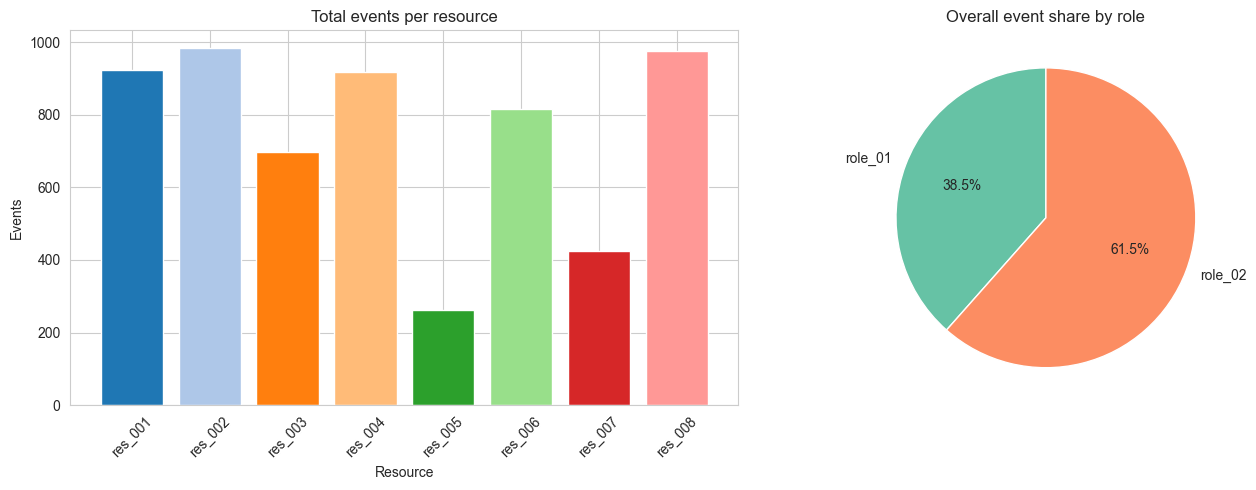

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resource_counts = df["resource"].value_counts().reindex(resources_sorted)
axes[0].bar(
    resource_counts.index,
    resource_counts.values,
    color=[RESOURCE_COLORS[r] for r in resource_counts.index],
)
axes[0].set_title("Total events per resource")
axes[0].set_xlabel("Resource")
axes[0].set_ylabel("Events")
axes[0].tick_params(axis="x", rotation=45)

role_counts = df["role"].value_counts().reindex(roles_sorted)
axes[1].pie(
    role_counts.values,
    labels=role_counts.index,
    autopct="%1.1f%%",
    colors=[ROLE_COLORS[r] for r in role_counts.index],
    startangle=90,
)
axes[1].set_title("Overall event share by role")

plt.tight_layout()
plt.show()

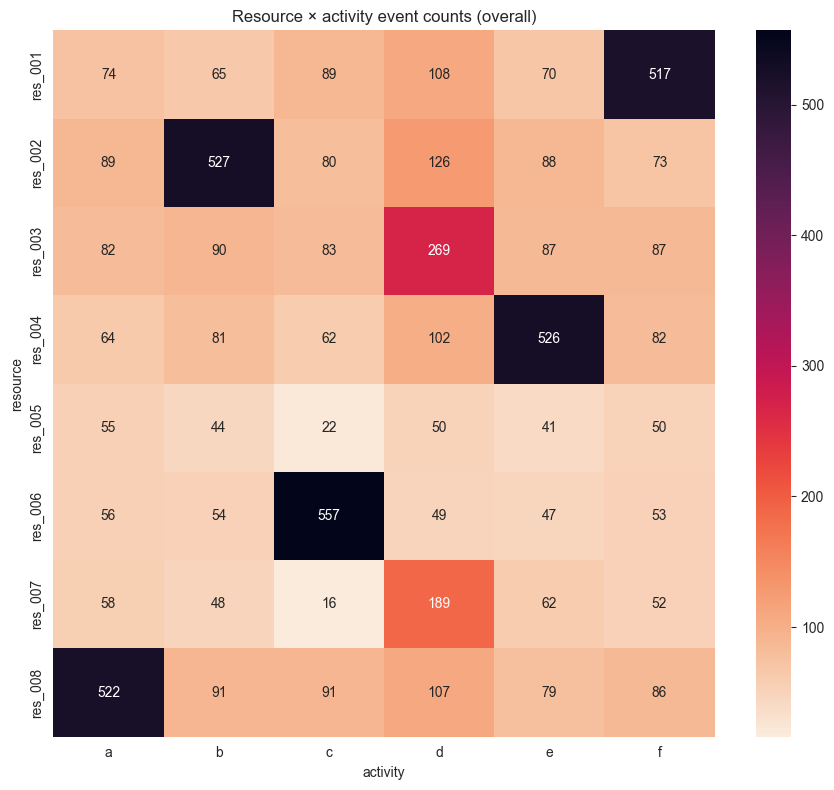

In [4]:
ra = pd.crosstab(df["resource"], df["activity"]).reindex(
    index=resources_sorted, columns=activities_sorted, fill_value=0
)

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(ra, annot=True, fmt="d", cmap="rocket_r", ax=ax)
ax.set_title("Resource × activity event counts (overall)")
plt.tight_layout()
plt.show()

## 3 · Time series with drift splitter lines

Every drift change point is drawn as a vertical line on these single-plot
charts so shifts in resource workload, pool size, and activity composition are
easy to spot.

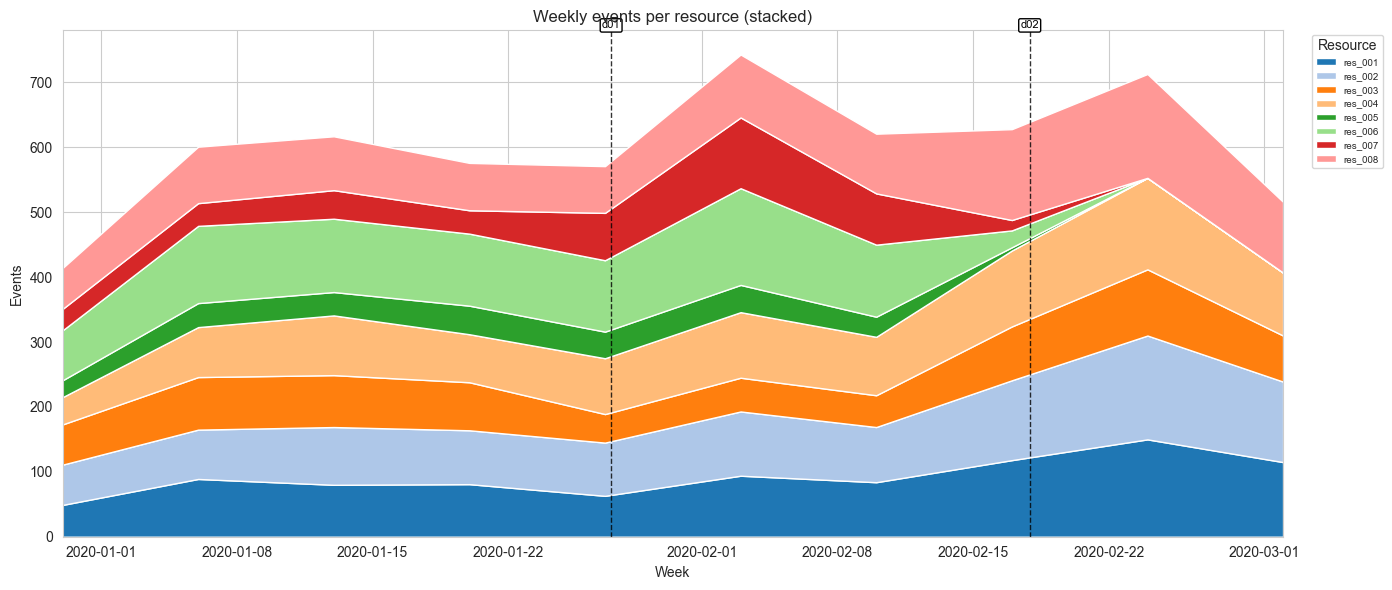

In [9]:
def _draw_drift_lines(ax, *, color="black", label_color="black"):
    ymax = ax.get_ylim()[1]
    for ts, lbl in zip(DRIFT_TIMESTAMPS, DRIFT_LABELS):
        ax.axvline(ts, color=color, linestyle="--", linewidth=1.0, alpha=0.8)
        ax.text(
            ts,
            ymax,
            lbl,
            ha="center",
            va="bottom",
            fontsize=8,
            color=label_color,
            bbox=dict(facecolor="white", edgecolor=color, boxstyle="round,pad=0.15"),
        )


weekly_resource = (
    df.groupby(["week", "resource"]).size()
    .unstack(fill_value=0)
    .reindex(columns=resources_sorted, fill_value=0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.stackplot(
    weekly_resource.index,
    weekly_resource.T.values,
    labels=weekly_resource.columns,
    colors=[RESOURCE_COLORS[r] for r in weekly_resource.columns],
)
ax.set_title("Weekly events per resource (stacked)")
ax.set_xlabel("Week")
ax.set_ylabel("Events")
ax.set_xlim(weekly_resource.index.min(), weekly_resource.index.max())
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=7,
    ncol=1,
    title="Resource",
)
_draw_drift_lines(ax)
plt.tight_layout()
plt.show()

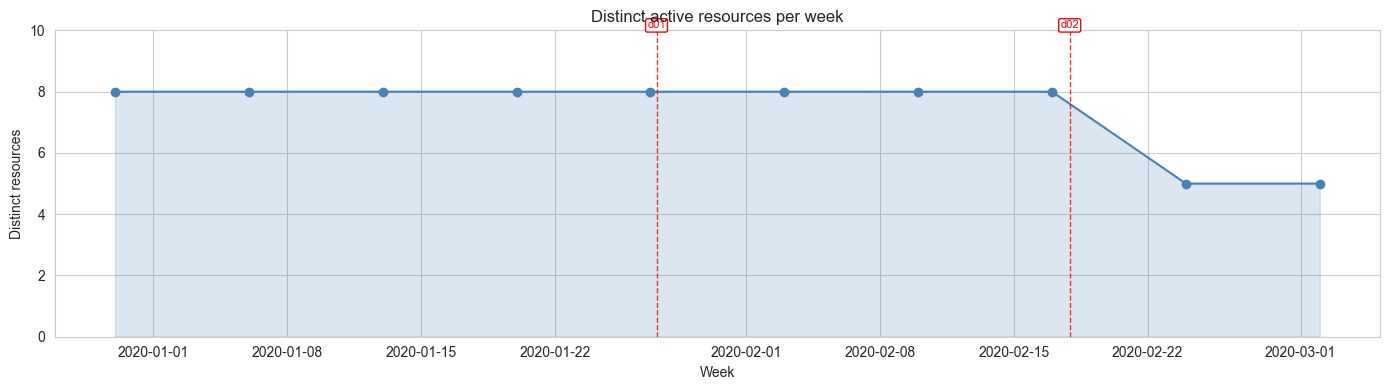

In [10]:
weekly_active = df.groupby("week")["resource"].nunique()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(
    weekly_active.index,
    weekly_active.values,
    marker="o",
    color="steelblue",
    linewidth=1.5,
)
ax.fill_between(weekly_active.index, weekly_active.values, alpha=0.2, color="steelblue")
ax.set_title("Distinct active resources per week")
ax.set_xlabel("Week")
ax.set_ylabel("Distinct resources")
ax.set_ylim(0, weekly_active.max() + 2)
_draw_drift_lines(ax, color="red", label_color="red")
plt.tight_layout()
plt.show()

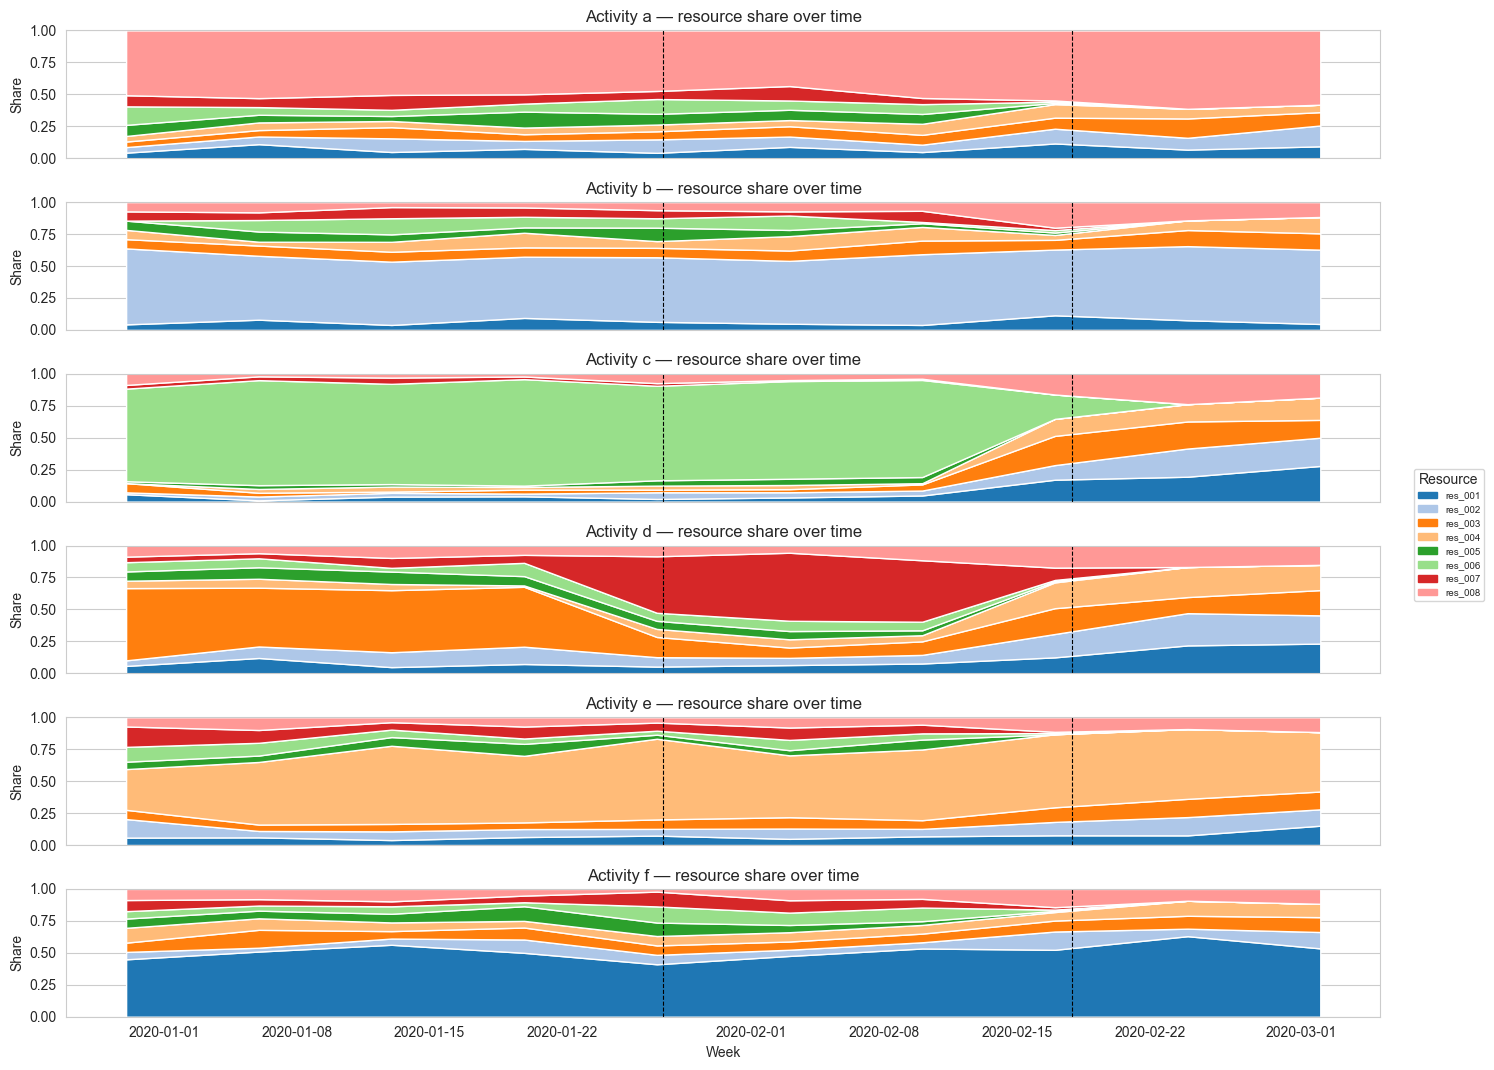

In [11]:
fig, axes = plt.subplots(
    len(activities_sorted), 1,
    figsize=(14, 1.8 * len(activities_sorted)),
    sharex=True,
)

for ax, act in zip(axes, activities_sorted):
    sub = df[df["activity"] == act]
    weekly = (
        sub.groupby(["week", "resource"]).size()
        .unstack(fill_value=0)
        .reindex(columns=resources_sorted, fill_value=0)
        .sort_index()
    )
    share = weekly.div(weekly.sum(axis=1), axis=0).fillna(0)
    ax.stackplot(
        share.index,
        share.T.values,
        colors=[RESOURCE_COLORS[r] for r in share.columns],
    )
    for ts in DRIFT_TIMESTAMPS:
        ax.axvline(ts, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(f"Activity {act} — resource share over time")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share")

axes[-1].set_xlabel("Week")

handles = [plt.Rectangle((0, 0), 1, 1, color=RESOURCE_COLORS[r]) for r in resources_sorted]
fig.legend(
    handles,
    resources_sorted,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=7,
    title="Resource",
)
plt.tight_layout()
plt.show()

## 4 · Pre vs post — single comparison cell

Edit `SELECTED_DRIFT` to any timestamp (e.g. one of `DRIFT_TIMESTAMPS`) and
re-run the cell below. `WINDOW_DAYS` controls how many days on each side of
the drift are included. Pre = events in `[drift − WINDOW_DAYS, drift)`;
post = events in `[drift, drift + WINDOW_DAYS)`. Pre on the left, post on the
right, with shared axes and colour scales.

selected drift: 2020-01-27 07:36:14.812695+00:00  (±30d)
pre  window:    [2019-12-28 07:36:14.812695+00:00, 2020-01-27 07:36:14.812695+00:00)
post window:    [2020-01-27 07:36:14.812695+00:00, 2020-02-26 07:36:14.812695+00:00)
pre:  2,243 events · 374 cases · 8 resources
post: 2,822 events · 472 cases · 8 resources


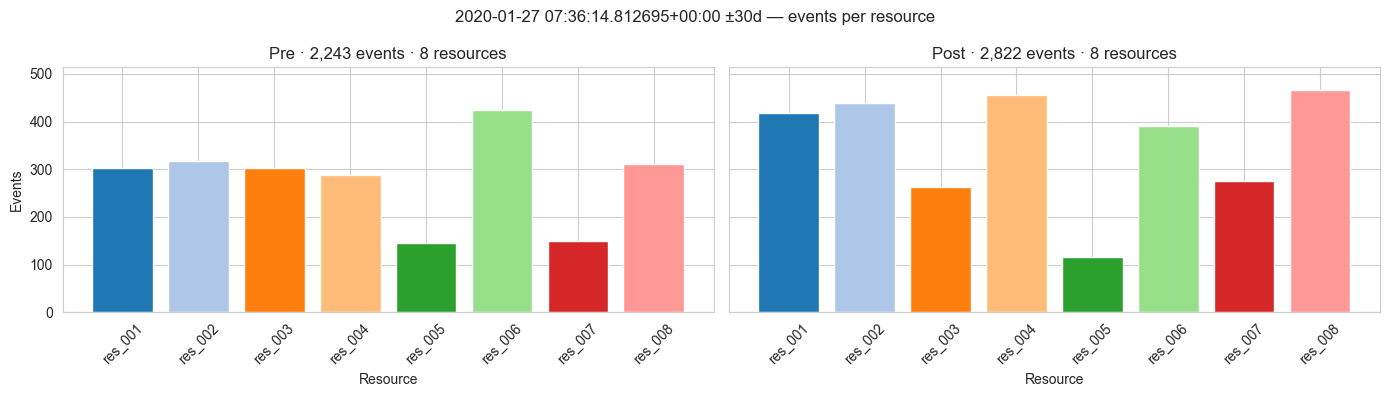

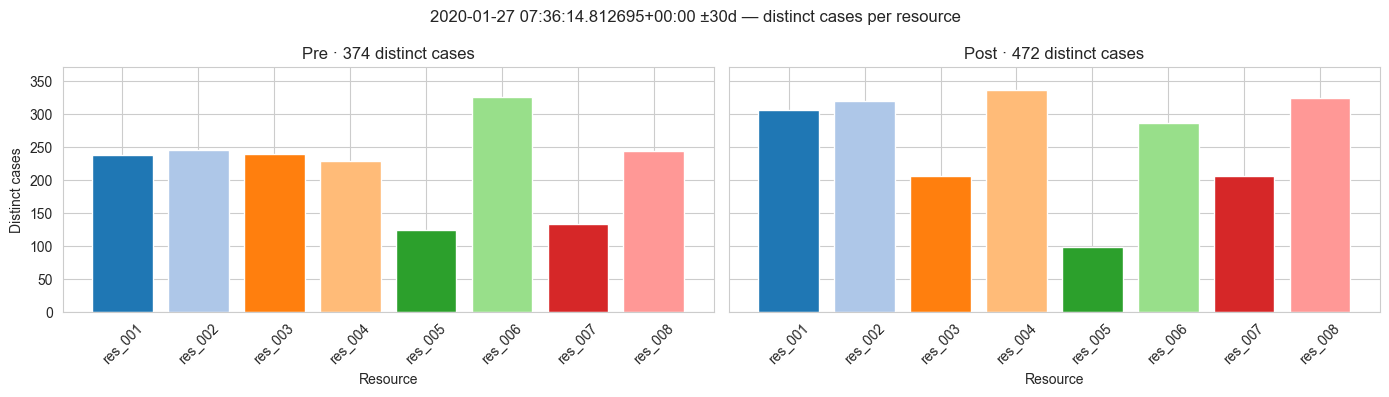

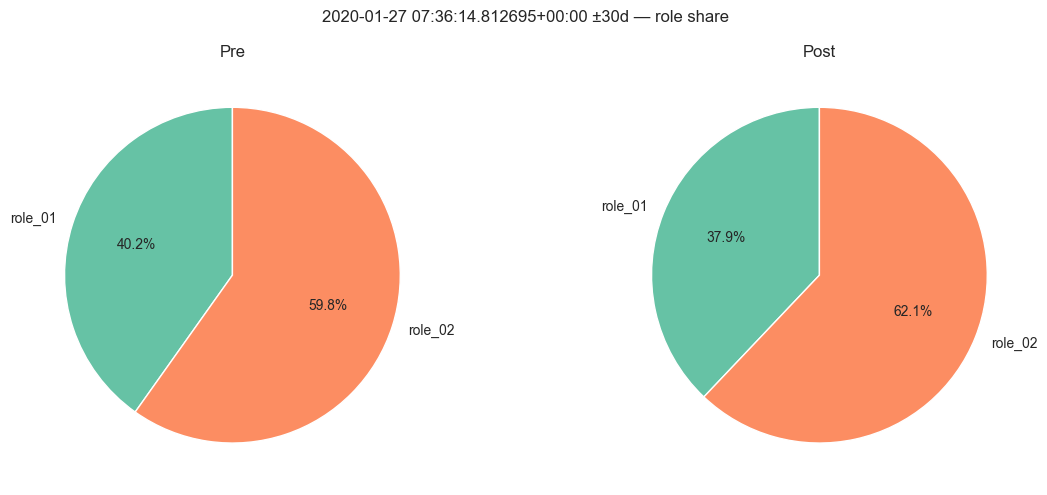

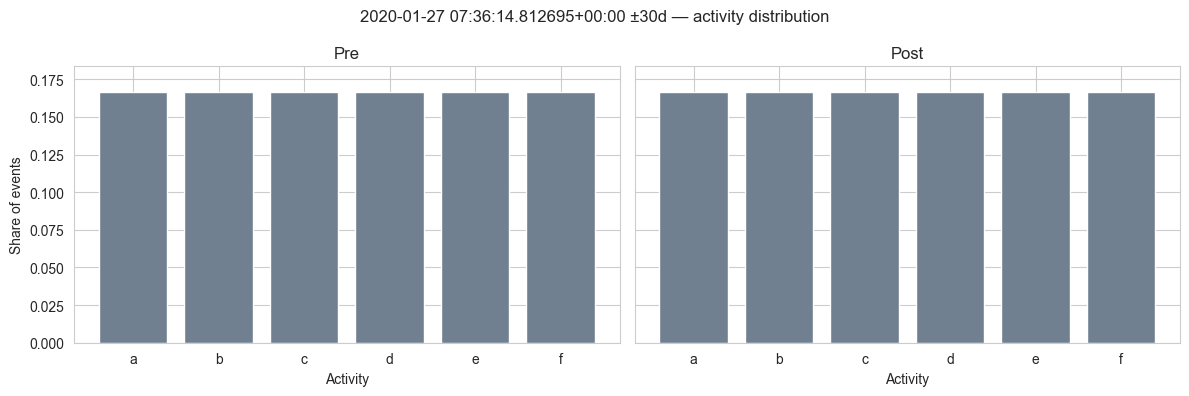

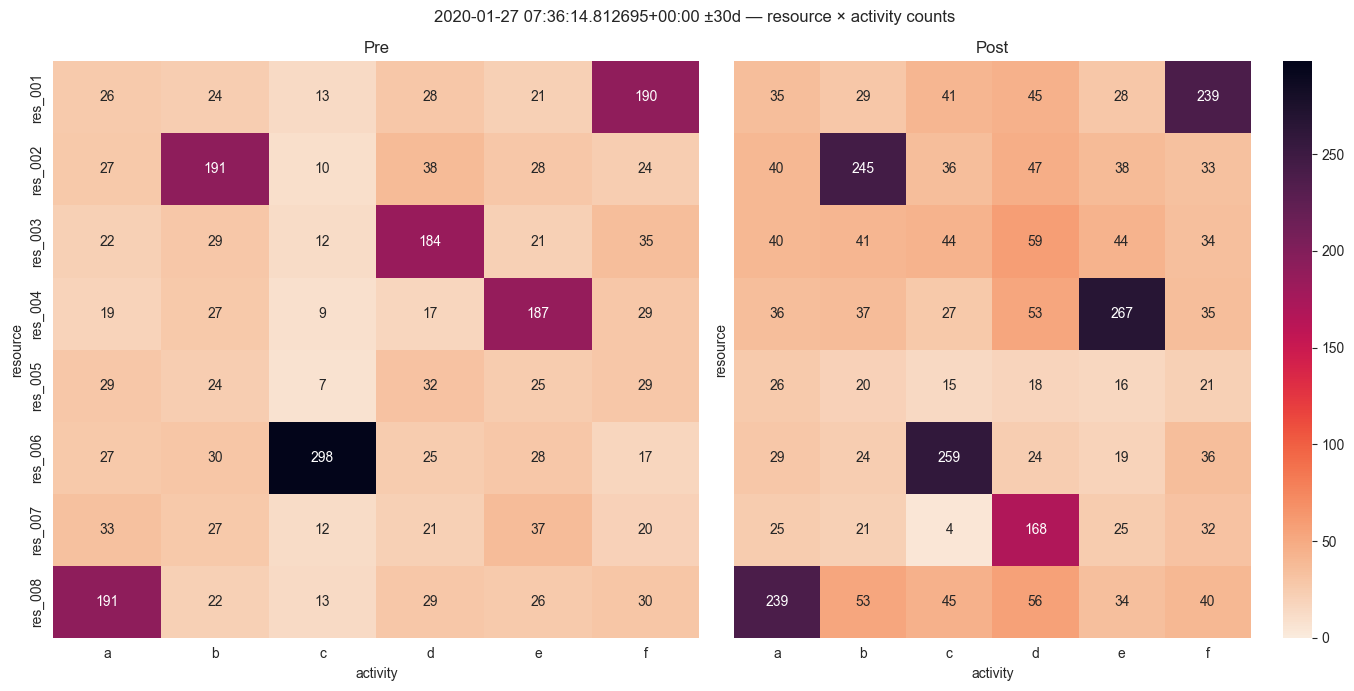

In [12]:
# === EDIT THESE TWO LINES ===
SELECTED_DRIFT = DRIFT_TIMESTAMPS[0]
WINDOW_DAYS = 30
# ============================

lo = SELECTED_DRIFT - pd.Timedelta(days=WINDOW_DAYS)
hi = SELECTED_DRIFT + pd.Timedelta(days=WINDOW_DAYS)
pre = df[(df["timestamp"] >= lo) & (df["timestamp"] < SELECTED_DRIFT)]
post = df[(df["timestamp"] >= SELECTED_DRIFT) & (df["timestamp"] < hi)]

print(f"selected drift: {SELECTED_DRIFT}  (±{WINDOW_DAYS}d)")
print(f"pre  window:    [{lo}, {SELECTED_DRIFT})")
print(f"post window:    [{SELECTED_DRIFT}, {hi})")
print(f"pre:  {len(pre):,} events · {pre['case_id'].nunique():,} cases · {pre['resource'].nunique()} resources")
print(f"post: {len(post):,} events · {post['case_id'].nunique():,} cases · {post['resource'].nunique()} resources")

# --- events per resource ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
series = [sub["resource"].value_counts().reindex(resources_sorted, fill_value=0)
          for sub in (pre, post)]
ymax = max(s.max() for s in series) or 1
for ax, c, title, sub in zip(axes, series, ["Pre", "Post"], [pre, post]):
    ax.bar(c.index, c.values, color=[RESOURCE_COLORS[r] for r in c.index])
    ax.set_title(f"{title} · {len(sub):,} events · {sub['resource'].nunique()} resources")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Resource")
axes[0].set_ylabel("Events")
axes[0].set_ylim(0, ymax * 1.1)
fig.suptitle(f"{SELECTED_DRIFT} ±{WINDOW_DAYS}d — events per resource", fontsize=12)
plt.tight_layout()
plt.show()

# --- distinct cases per resource ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
series = [sub.groupby("resource")["case_id"].nunique().reindex(resources_sorted, fill_value=0)
          for sub in (pre, post)]
ymax = max(s.max() for s in series) or 1
for ax, c, title, sub in zip(axes, series, ["Pre", "Post"], [pre, post]):
    ax.bar(c.index, c.values, color=[RESOURCE_COLORS[r] for r in c.index])
    ax.set_title(f"{title} · {sub['case_id'].nunique():,} distinct cases")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Resource")
axes[0].set_ylabel("Distinct cases")
axes[0].set_ylim(0, ymax * 1.1)
fig.suptitle(f"{SELECTED_DRIFT} ±{WINDOW_DAYS}d — distinct cases per resource", fontsize=12)
plt.tight_layout()
plt.show()

# --- role share (pies) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, sub, title in zip(axes, [pre, post], ["Pre", "Post"]):
    rc = sub["role"].value_counts().reindex(roles_sorted, fill_value=0)
    rc = rc[rc > 0]
    ax.pie(
        rc.values,
        labels=rc.index,
        autopct="%1.1f%%",
        colors=[ROLE_COLORS[r] for r in rc.index],
        startangle=90,
    )
    ax.set_title(title)
fig.suptitle(f"{SELECTED_DRIFT} ±{WINDOW_DAYS}d — role share", fontsize=12)
plt.tight_layout()
plt.show()

# --- activity distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
series = [sub["activity"].value_counts(normalize=True).reindex(activities_sorted, fill_value=0)
          for sub in (pre, post)]
ymax = max(s.max() for s in series) or 1
for ax, c, title in zip(axes, series, ["Pre", "Post"]):
    ax.bar(c.index, c.values, color="slategray")
    ax.set_title(title)
    ax.set_xlabel("Activity")
axes[0].set_ylabel("Share of events")
axes[0].set_ylim(0, ymax * 1.1)
fig.suptitle(f"{SELECTED_DRIFT} ±{WINDOW_DAYS}d — activity distribution", fontsize=12)
plt.tight_layout()
plt.show()

# --- resource × activity heatmaps ---
pre_ct = pd.crosstab(pre["resource"], pre["activity"]).reindex(
    index=resources_sorted, columns=activities_sorted, fill_value=0
)
post_ct = pd.crosstab(post["resource"], post["activity"]).reindex(
    index=resources_sorted, columns=activities_sorted, fill_value=0
)
vmax = max(pre_ct.values.max(), post_ct.values.max()) or 1
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
sns.heatmap(pre_ct, annot=True, fmt="d", cmap="rocket_r",
            vmin=0, vmax=vmax, ax=axes[0], cbar=False)
axes[0].set_title("Pre")
sns.heatmap(post_ct, annot=True, fmt="d", cmap="rocket_r",
            vmin=0, vmax=vmax, ax=axes[1])
axes[1].set_title("Post")
fig.suptitle(f"{SELECTED_DRIFT} ±{WINDOW_DAYS}d — resource × activity counts", fontsize=12)
plt.tight_layout()
plt.show()